In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os
import plotly.graph_objects as go

from tqdm import tqdm

p_rad = 0.5
mtype = 'octa'
root = os.path.join('/home/mmccraw/dev/data/26-01-01/grant/friction-surface', mtype)

def load_data(root, nv):
    paths = np.array(os.listdir(os.path.join(root, str(nv))))
    arads = np.array([float(p.split('-')[3]) for p in paths])

    mus = []
    separations = []

    for arad in tqdm(np.unique(arads), total=len(np.unique(arads))):
        _mus = []
        _separations = []
        for path in paths[arads == arad]:
            data = np.load(os.path.join(root, str(nv), path))
            _mus.append(data['mu'])
            _separations.append(data['separation'])
        mus.append(np.concatenate(_mus))
        separations.append(np.concatenate(_separations))
    return {
        'mu': mus,
        'separation': separations,
        'arad': np.unique(arads)
    }

data_19 = load_data(root, 19)
data_39 = load_data(root, 39)
data_103 = load_data(root, 103)

  6%|▌         | 6/100 [00:00<00:05, 15.98it/s]

100%|██████████| 80/80 [00:08<00:00,  9.09it/s]


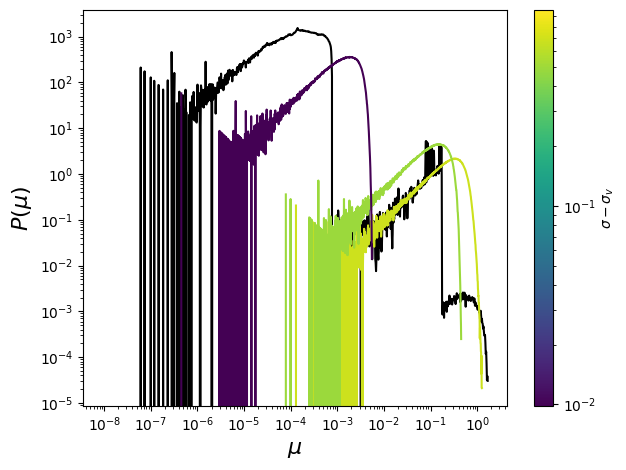

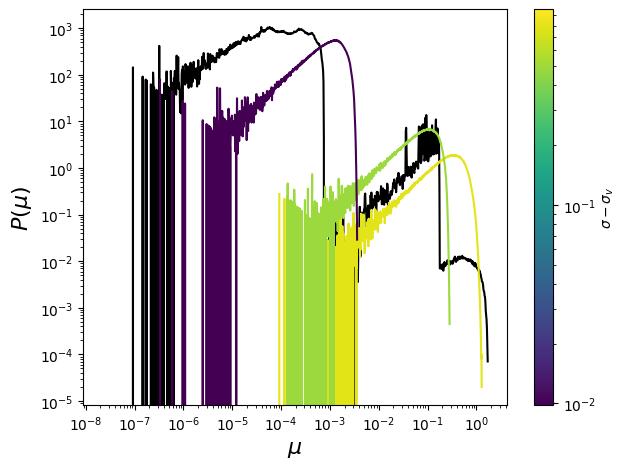

IndexError: index 99 is out of bounds for axis 0 with size 80

In [2]:
list_of_indices = [
    [1, 30, 50, 99],
    [1, 20, 50, 99],
    [1, 10, 50, 99],
]

for data, name, indices in zip([data_19, data_39, data_103], ['19', '39', '103'], list_of_indices):

    cmap = plt.cm.viridis
    arad_norm = LogNorm(2 * min(p_rad - data['arad'][indices]), 2 * max(p_rad - data['arad'][indices]))
    # arad_norm = plt.Normalize(2 * min(p_rad - data['arad'][indices]), 2 * max(p_rad - data['arad'][indices]))

    for i in indices:
        mu_vals = data['mu'][i]
        bins = np.logspace(
            np.log10(min(mu_vals[mu_vals > 0])),
            np.log10(max(mu_vals)),
            1_000,
        )
        p_mu, edges = np.histogram(mu_vals, bins=bins, density=True)
        mu = (edges[1:] + edges[:-1]) / 2.0
        if i == 1:
            c = 'k'
        else:
            c = cmap(arad_norm(2.0 * (p_rad - data['arad'][i])))
        plt.plot(mu, p_mu, c=c)

    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel(r'$\mu$', fontsize=16)
    plt.ylabel(r'$P(\mu)$', fontsize=16)

    sm = plt.cm.ScalarMappable(norm=arad_norm, cmap=cmap)
    sm.set_array(2 * (p_rad - data['arad'][indices]))
    cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\sigma - \sigma_v$')

    plt.tight_layout()
    plt.savefig(f'new-figures/{mtype}-{name}-friction-distributions.png', dpi=600)
    plt.show()

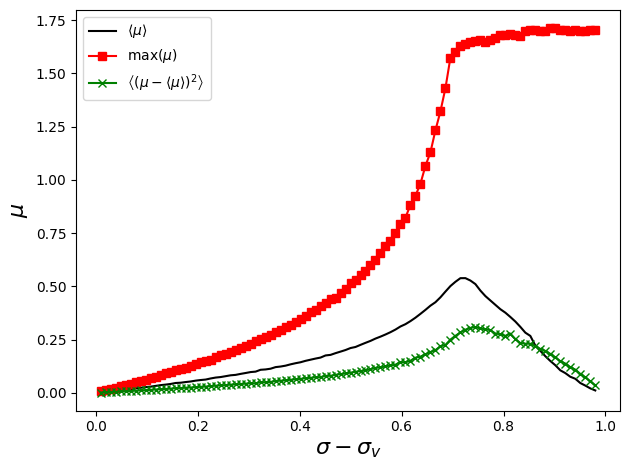

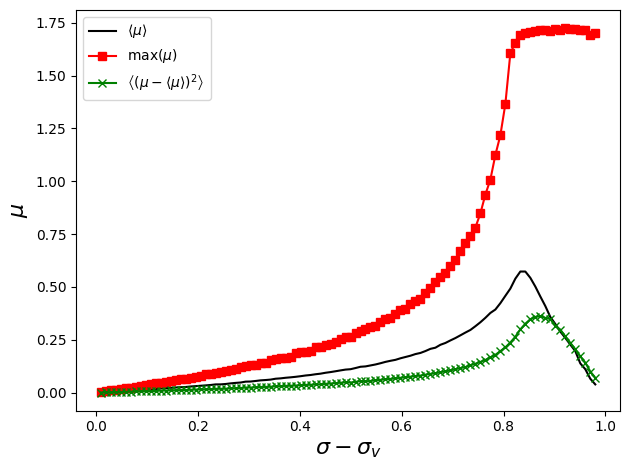

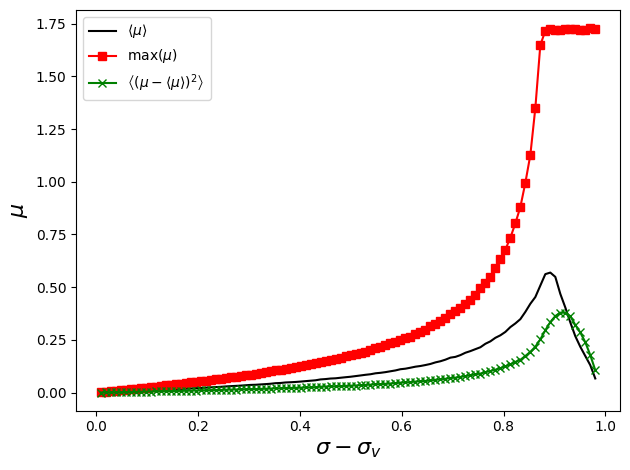

In [ ]:
for data, name in zip([data_19, data_39, data_103], ['19', '39', '103']):

    x = 2.0 * (p_rad - data['arad'])
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    # x /= x[np.argmax(y_mean)]

    plt.plot(x, y_mean, c='k', label=r'$\langle \mu \rangle$')
    plt.plot(x, y_max, c='r', marker='s', label=r'$\max(\mu)$')
    plt.plot(x, y_std, c='g', marker='x', label=r'$\left \langle (\mu - \langle \mu \rangle)^2 \right \rangle$')
    # plt.axvline(1.0)

    plt.legend()
    plt.xlabel(r'$\sigma - \sigma_v$', fontsize=16)
    plt.ylabel(r'$\mu$', fontsize=16)
    
    plt.tight_layout()
    plt.savefig(f'new-figures/{mtype}-{name}-friction-curves.png', dpi=600)
    plt.show()

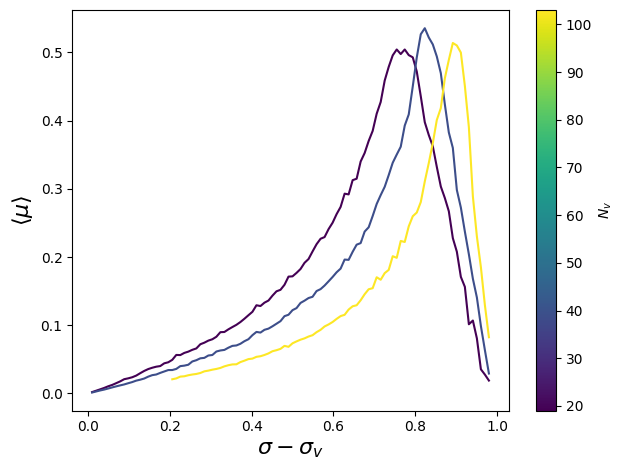

In [3]:
names = ['19', '39', '103']

nvs = [int(n) for n in names]

cmap = plt.cm.viridis
nv_norm = plt.Normalize(min(nvs), max(nvs))

for data, name, nv in zip([data_19, data_39, data_103], names, nvs):

    x = 2.0 * (p_rad - data['arad'])
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    plt.plot(x, y_mean, c=cmap(nv_norm(nv)))

plt.xlabel(r'$\sigma - \sigma_v$', fontsize=16)
plt.ylabel(r'$\langle \mu \rangle$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.tight_layout()
plt.savefig(f'new-figures/{mtype}-mean-friction.png', dpi=600)
plt.show()

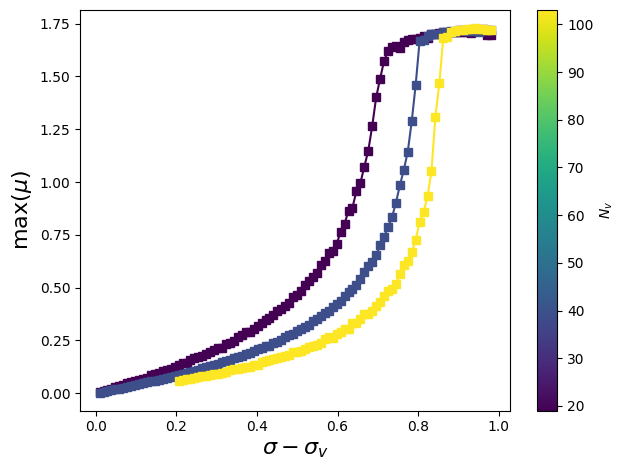

In [4]:
names = ['19', '39', '103']

nvs = [int(n) for n in names]

cmap = plt.cm.viridis
nv_norm = plt.Normalize(min(nvs), max(nvs))

for data, name, nv in zip([data_19, data_39, data_103], names, nvs):

    x = 2.0 * (p_rad - data['arad'])
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    plt.plot(x, y_max, marker='s', c=cmap(nv_norm(nv)))
    # plt.plot(x, y_std, marker='x', c=cmap(nv_norm(nv)))

plt.xlabel(r'$\sigma - \sigma_v$', fontsize=16)
plt.ylabel(r'$\max(\mu)$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.tight_layout()
plt.savefig(f'new-figures/{mtype}-max-friction.png', dpi=600)
plt.show()

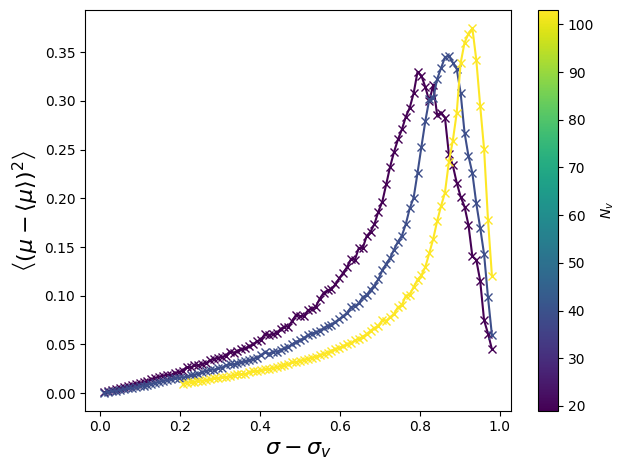

In [5]:
names = ['19', '39', '103']

nvs = [int(n) for n in names]

cmap = plt.cm.viridis
nv_norm = plt.Normalize(min(nvs), max(nvs))

for data, name, nv in zip([data_19, data_39, data_103], names, nvs):

    x = 2.0 * (p_rad - data['arad'])
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    plt.plot(x, y_std, marker='x', c=cmap(nv_norm(nv)))

plt.xlabel(r'$\sigma - \sigma_v$', fontsize=16)
plt.ylabel(r'$\left \langle (\mu - \langle \mu \rangle)^2 \right \rangle$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.tight_layout()
plt.savefig(f'new-figures/{mtype}-std-friction.png', dpi=600)
plt.show()

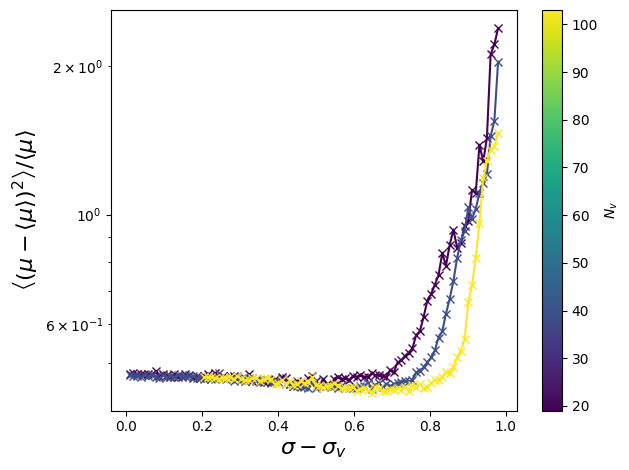

In [6]:
names = ['19', '39', '103']

nvs = [int(n) for n in names]

cmap = plt.cm.viridis
nv_norm = plt.Normalize(min(nvs), max(nvs))

for data, name, nv in zip([data_19, data_39, data_103], names, nvs):

    x = 2.0 * (p_rad - data['arad'])
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    plt.plot(x, y_std / y_mean, marker='x', c=cmap(nv_norm(nv)))

plt.xlabel(r'$\sigma - \sigma_v$', fontsize=16)
plt.ylabel(r'$\left \langle (\mu - \langle \mu \rangle)^2 \right \rangle / \langle \mu \rangle$', fontsize=16)
plt.yscale('log')

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.tight_layout()
plt.savefig(f'new-figures/{mtype}-normstd-friction.png', dpi=600)
plt.show()

In [7]:
# root = "/home/mmccraw/dev/data/26-01-01/grant/friction-surface/ico/93/nv-93-arad-0.1031-theta-0.0000-phi-0.0000.npz"
root = "/home/mmccraw/dev/data/26-01-01/grant/friction-surface/octa/103/nv-103-arad-0.07369999999999999-theta-0.0000-phi-0.0000.npz"
# root = "/home/mmccraw/dev/data/26-01-01/grant/friction-surface/ico/13/nv-13-arad-0.07369999999999999-theta-0.0000-phi-0.0000.npz"
# root = "/home/mmccraw/dev/data/26-01-01/grant/friction-surface/ico/13/nv-13-arad-0.1031-theta-0.0000-phi-0.1745.npz"
# root = "/home/mmccraw/dev/data/26-01-01/grant/friction-surface/ico/13/nv-13-arad-0.01-theta-0.0000-phi-0.0000.npz"
# root = "/home/mmccraw/dev/data/26-01-01/grant/friction-surface/ico/13/nv-13-arad-0.01-theta-0.0000-phi-0.1745.npz"
data = np.load(root)
# plt.scatter(data['theta'], data['phi'], c=data['separation'], s=0.05)
# mu = data['mu']
# plt.hist(mu)


In [8]:
from scipy.spatial import ConvexHull

X = np.sin(data['theta']) * np.cos(data['phi'])
Y = np.sin(data['theta']) * np.sin(data['phi'])
Z = np.cos(data['theta'])

# triangulate the points on the sphere via their convex hull
hull = ConvexHull(np.column_stack([X, Y, Z]))

fig = go.Figure(
    go.Mesh3d(
        x=X, y=Y, z=Z,
        i=hull.simplices[:, 0],
        j=hull.simplices[:, 1],
        k=hull.simplices[:, 2],
        intensity=data['separation'],
        colorscale="Viridis",
        colorbar=dict(title="μ"),
    )
)
fig.update_layout(scene=dict(aspectmode="data"))
fig.show()